# Tech Challenge | Previsão da direção do IBOVESPA no dia seguinte

## Contexto do problema

O objetivo deste notebook é construir um modelo preditivo capaz de estimar se o **fechamento do IBOVESPA no dia seguinte** será **maior** ou **menor** que o fechamento do dia atual.

Em termos práticos, a variável alvo é:

- **1**: o fechamento de amanhã é maior que o fechamento de hoje
- **0**: o fechamento de amanhã é menor ou igual ao fechamento de hoje

O foco aqui não é apenas buscar a maior acurácia possível, mas montar um pipeline **tecnicamente defensável**, respeitando a natureza temporal da série e evitando decisões metodológicas que contaminem a avaliação final.

## Sobre o IBOVESPA

O **Ibovespa** é o principal índice de referência do mercado acionário brasileiro. Ele sintetiza o comportamento de uma carteira teórica de ações representativas da bolsa brasileira e, por isso, funciona como uma medida resumida do humor do mercado local.

Prever a direção diária do índice é um problema desafiador, porque séries financeiras costumam apresentar:

- muito ruído
- mudanças de regime ao longo do tempo
- baixa previsibilidade no curtíssimo prazo
- forte risco de overfitting quando o pipeline não respeita a cronologia

Por isso, a lógica deste notebook foi organizada para responder à pergunta de negócio sem perder o rigor estatístico.

## Estratégia deste notebook

A sequência adotada será:

1. leitura e limpeza da base histórica
2. análise exploratória e checagens de consistência
3. engenharia de atributos sem vazamento de informação
4. definição correta do target
5. separação temporal em **treino, validação e teste**
6. comparação de modelos
7. escolha do modelo campeão usando **apenas validação**
8. avaliação final no conjunto de teste com os **últimos 30 dias**
9. conclusão técnica com limitações e próximos passos

In [28]:

# ============================================================
# 1. Imports e configurações gerais
# ============================================================

from pathlib import Path
import warnings
import unicodedata

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC

# XGBoost é opcional: se não estiver instalado, o notebook continua funcionando.
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

RANDOM_STATE = 42
VAL_SIZE = 60
TEST_SIZE = 30
THRESHOLD_GRID = np.arange(0.35, 0.66, 0.01)

# Informe aqui o nome do arquivo CSV exportado do Investing.
CSV_CANDIDATES = [
    "Dados Históricos - Ibovespa.csv",
    "Dados Históricos - Ibovespa.csv",
    "IBOVESPA_historicos_012020_032026.csv",
    "IBOVESPA_historicos.csv",
]

# Caso queira restringir o período de treino, informe uma data aqui.
# Exemplo: TRAIN_START_DATE = "2010-01-01"
TRAIN_START_DATE = None

## Leitura e limpeza dos dados

O arquivo exportado do Investing costuma vir com colunas textuais em português, como:

- `Data`
- `Último`
- `Abertura`
- `Máxima`
- `Mínima`
- `Vol.`
- `Var%`

Antes de modelar, precisamos transformar essas colunas em um formato numérico e cronologicamente consistente.

In [29]:

# ============================================================
# 2. Funções auxiliares de localização, parsing e limpeza
# ============================================================

def find_csv_file(candidates):
    """Procura o CSV em caminhos comuns do notebook/projeto."""

    search_roots = [
        Path.cwd(),
        Path.cwd() / "data",
        Path.cwd() / "raw",
        Path.cwd() / "data" / "raw",
        Path.cwd().parent,
        Path.cwd().parent / "data",
        Path.cwd().parent / "raw",
        Path.cwd().parent / "data" / "raw",
    ]

    for root in search_roots:
        for name in candidates:
            candidate = root / name
            if candidate.exists():
                return candidate.resolve()

    raise FileNotFoundError(
        "Nenhum arquivo CSV foi encontrado. Ajuste a lista CSV_CANDIDATES ou mova o arquivo para uma pasta conhecida."
    )


def strip_accents(text):
    return "".join(
        ch for ch in unicodedata.normalize("NFKD", str(text))
        if not unicodedata.combining(ch)
    )


def clean_col(col):
    return (
        strip_accents(col)
        .replace(".", "")
        .replace("%", "")
        .strip()
        .lower()
    )


def coerce_pt_number(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().replace(".", "").replace(",", ".")
    try:
        return float(s)
    except Exception:
        return np.nan


def parse_pt_volume(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip()
    if s == "-" or s == "":
        return np.nan

    mult = 1
    if s[-1].upper() == "K":
        mult = 1e3
        s = s[:-1]
    elif s[-1].upper() == "M":
        mult = 1e6
        s = s[:-1]
    elif s[-1].upper() == "B":
        mult = 1e9
        s = s[:-1]

    try:
        return float(s.replace(".", "").replace(",", ".")) * mult
    except Exception:
        return np.nan


def standardize_investing_pt(df_raw):
    """Padroniza o CSV do Investing para um formato limpo e previsível."""

    cols_map = {clean_col(c): c for c in df_raw.columns}
    rename = {}

    for key, original in cols_map.items():
        if "data" in key:
            rename[original] = "data"
        elif "ultimo" in key or "fechamento" in key:
            rename[original] = "close"
        elif "abert" in key:
            rename[original] = "open"
        elif "max" in key:
            rename[original] = "high"
        elif "min" in key:
            rename[original] = "low"
        elif "vol" in key:
            rename[original] = "volume"
        elif "var" in key:
            rename[original] = "var_pct"

    df = df_raw.rename(columns=rename).copy()

    required = ["data", "close", "open", "high", "low"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Colunas obrigatórias ausentes após padronização: {missing}")

    df["data"] = pd.to_datetime(df["data"], dayfirst=True, errors="coerce")

    for col in ["close", "open", "high", "low"]:
        df[col] = df[col].apply(coerce_pt_number)

    if "volume" in df.columns:
        df["volume"] = df["volume"].apply(parse_pt_volume)

    if "var_pct" in df.columns:
        df["var_pct"] = df["var_pct"].astype(str).str.replace("%", "", regex=False)
        df["var_pct"] = df["var_pct"].apply(coerce_pt_number)

    df = (
        df.dropna(subset=["data", "close", "open", "high", "low"])
          .sort_values("data")
          .drop_duplicates(subset=["data"])
          .reset_index(drop=True)
    )

    return df


csv_path = find_csv_file(CSV_CANDIDATES)
print(f"Arquivo localizado: {csv_path}")

df_raw = pd.read_csv(csv_path)
df = standardize_investing_pt(df_raw)

print(f"Formato da base após limpeza: {df.shape}")
print(f"Período disponível: {df['data'].min().date()} até {df['data'].max().date()}")

display(df.head())
display(df.tail())

Arquivo localizado: /Users/isabellarodriguessandes/projects/previsao-ibovespa-machine-learning/data/raw/Dados Históricos - Ibovespa.csv
Formato da base após limpeza: (5000, 7)
Período disponível: 2006-01-02 até 2026-03-10


,data,close,open,high,low,volume,var_pct
0,2006-01-02,33507.0,33462.0,33519.0,3286.0,72320000.0,0.15
1,2006-01-03,34541.0,33507.0,34563.0,33507.0,148380000.0,3.09
2,2006-01-04,35002.0,3454.0,35223.0,3454.0,147130000.0,1.33
3,2006-01-05,34936.0,35006.0,35088.0,34681.0,142070000.0,-0.19
4,2006-01-06,35475.0,3517.0,35529.0,3494.0,115090000.0,1.54


,data,close,open,high,low,volume,var_pct
4995,2026-03-04,185366.0,18311.0,186306.0,18311.0,9.110000e+09,1.24
4996,2026-03-05,180464.0,185365.0,185366.0,179895.0,1.060000e+10,-2.64
4997,2026-03-06,179365.0,180463.0,181091.0,178556.0,9.920000e+09,-0.61
4998,2026-03-09,180915.0,179367.0,181952.0,177637.0,1.142000e+10,0.86
4999,2026-03-10,183447.0,180921.0,185324.0,180693.0,1.008000e+10,1.40


## Checagens de consistência

Antes da engenharia de atributos, é importante garantir que a base:

- está em ordem cronológica crescente
- não possui datas duplicadas
- possui pelo menos dois anos de histórico, como exige o enunciado

In [30]:

# ============================================================
# 3. Sanity checks
# ============================================================

assert df["data"].is_monotonic_increasing, "A série não está em ordem cronológica crescente."
assert df["data"].duplicated().sum() == 0, "Existem datas duplicadas na base."

dias_cobertos = (df["data"].max() - df["data"].min()).days
anos_cobertos = dias_cobertos / 365.25

print(f"Anos aproximados cobertos pela base: {anos_cobertos:.2f}")
print("Requisito mínimo de 2 anos atendido:", anos_cobertos >= 2)

Anos aproximados cobertos pela base: 20.18
Requisito mínimo de 2 anos atendido: True


## Análise exploratória

A etapa exploratória ajuda a entender o comportamento da série, identificar volatilidade, tendência e plausibilidade dos dados antes da modelagem.

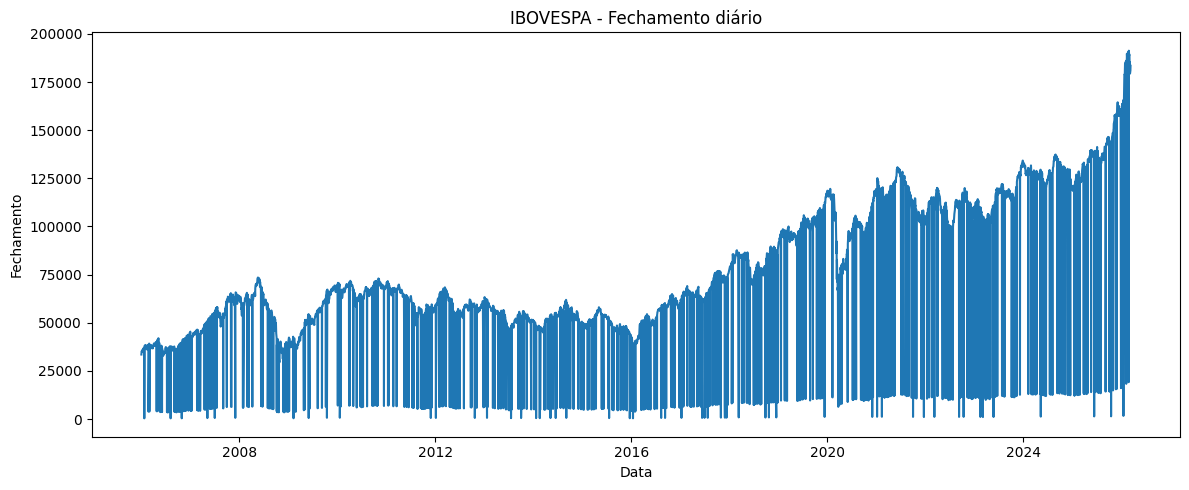

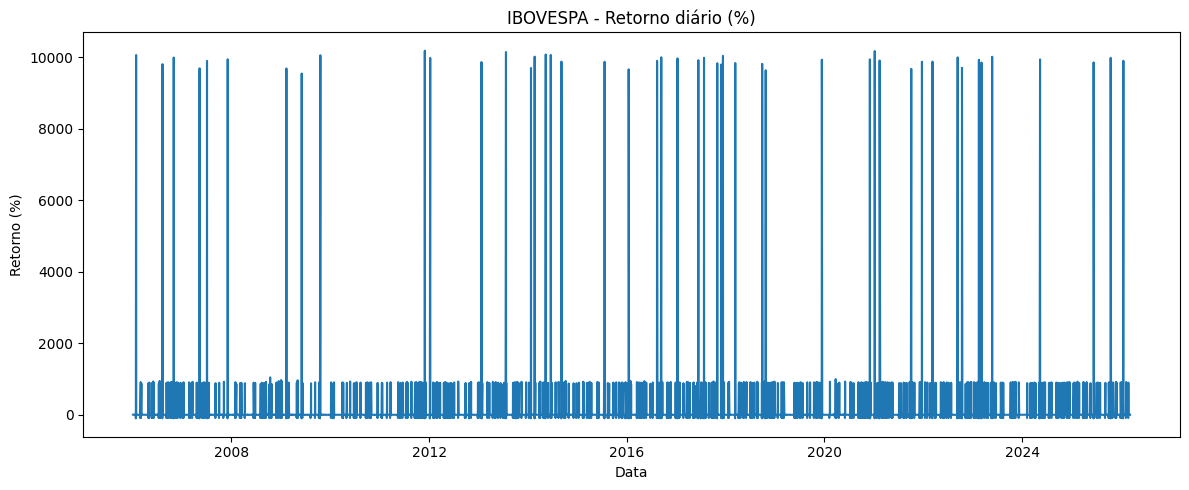

,count,mean,std,min,25%,50%,75%,max
close,5000.0,7.115498e+04,3.728512e+04,374.000000,4.997150e+04,6.286850e+04,1.028152e+05,1.912470e+05
retorno_diario_pct,4999.0,1.605079e+02,9.828396e+02,-99.037057,-1.034408e+00,7.875143e-02,1.224213e+00,1.018481e+04
volume,4999.0,5.596427e+08,2.259351e+09,112100.000000,2.830000e+06,4.480000e+06,1.107000e+07,2.487000e+10
var_pct,5000.0,4.757200e-02,1.641992e+00,-14.780000,-7.800000e-01,6.000000e-02,9.000000e-01,1.466000e+01


In [31]:

# ============================================================
# 4. EDA rápida
# ============================================================

fig = plt.figure(figsize=(12, 5))
plt.plot(df["data"], df["close"])
plt.title("IBOVESPA - Fechamento diário")
plt.xlabel("Data")
plt.ylabel("Fechamento")
plt.tight_layout()
plt.show()

df["retorno_diario_pct"] = df["close"].pct_change() * 100

fig = plt.figure(figsize=(12, 5))
plt.plot(df["data"], df["retorno_diario_pct"])
plt.title("IBOVESPA - Retorno diário (%)")
plt.xlabel("Data")
plt.ylabel("Retorno (%)")
plt.tight_layout()
plt.show()

display(df[["close", "retorno_diario_pct", "volume", "var_pct"]].describe().T)

## Engenharia de atributos

Como se trata de uma série temporal, todas as variáveis explicativas devem usar apenas informação **disponível até o fechamento do dia atual**.

A ideia aqui é transformar a série de preços em sinais mais úteis para o modelo, por exemplo:

- retornos defasados
- médias móveis
- distâncias para médias
- volatilidade recente
- momentum
- RSI, MACD, Bollinger e Stochastic
- amplitude intradiária e corpo do candle
- calendário

In [32]:

# ============================================================
# 5. Funções de indicadores técnicos
# ============================================================

def rsi(prices, period=14):
    delta = prices.diff()
    gains = delta.clip(lower=0).rolling(period).mean()
    losses = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gains / losses
    return 100 - (100 / (1 + rs))


def macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    hist = macd_line - signal_line
    return macd_line, signal_line, hist


def bollinger_pct_b(prices, window=20, n_std=2):
    ma = prices.rolling(window).mean()
    std = prices.rolling(window).std()
    upper = ma + n_std * std
    lower = ma - n_std * std
    pct_b = (prices - lower) / (upper - lower)
    return pct_b


def stochastic_k(close, high, low, window=14):
    rolling_low = low.rolling(window).min()
    rolling_high = high.rolling(window).max()
    return 100 * (close - rolling_low) / (rolling_high - rolling_low)

In [33]:

# ============================================================
# 6. Criação das features e do target
# ============================================================

df_feat = df.copy()

# ---------------------------
# Target aderente ao desafio
# ---------------------------
# 1 -> fechamento de amanhã maior que o de hoje
# 0 -> fechamento de amanhã menor ou igual ao de hoje
df_feat["next_close"] = df_feat["close"].shift(-1)
df_feat["target"] = (df_feat["next_close"] > df_feat["close"]).astype(int)

# ---------------------------
# Retornos e defasagens
# ---------------------------
df_feat["ret_1d"] = df_feat["close"].pct_change()
for lag in [1, 2, 3, 5, 10]:
    df_feat[f"ret_lag_{lag}"] = df_feat["ret_1d"].shift(lag)

# ---------------------------
# Médias móveis e distâncias
# ---------------------------
for window in [5, 10, 20, 30]:
    df_feat[f"sma_{window}"] = df_feat["close"].rolling(window).mean()
    df_feat[f"dist_sma_{window}"] = (df_feat["close"] / df_feat[f"sma_{window}"]) - 1

# ---------------------------
# Volatilidade e momentum
# ---------------------------
for window in [5, 10, 20]:
    df_feat[f"vol_{window}"] = df_feat["ret_1d"].rolling(window).std()

for window in [3, 5, 10]:
    df_feat[f"mom_{window}"] = df_feat["close"] / df_feat["close"].shift(window) - 1

# ---------------------------
# Indicadores técnicos
# ---------------------------
df_feat["rsi_14"] = rsi(df_feat["close"], period=14)

macd_line, signal_line, macd_hist = macd(df_feat["close"])
df_feat["macd"] = macd_line
df_feat["macd_signal"] = signal_line
df_feat["macd_hist"] = macd_hist

df_feat["bb_pct_b"] = bollinger_pct_b(df_feat["close"], window=20, n_std=2)
df_feat["stoch_k"] = stochastic_k(df_feat["close"], df_feat["high"], df_feat["low"], window=14)

# ---------------------------
# Candle e microestrutura simples
# ---------------------------
df_feat["range_intraday"] = df_feat["high"] - df_feat["low"]
df_feat["body"] = df_feat["close"] - df_feat["open"]
df_feat["pos_close_range"] = (df_feat["close"] - df_feat["low"]) / (df_feat["high"] - df_feat["low"])

# ---------------------------
# Calendário
# ---------------------------
df_feat["day_of_week"] = df_feat["data"].dt.dayofweek
df_feat["month"] = df_feat["data"].dt.month

# ---------------------------
# Tratamento final
# ---------------------------
df_feat = df_feat.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

if TRAIN_START_DATE is not None:
    df_feat = df_feat[df_feat["data"] >= pd.to_datetime(TRAIN_START_DATE)].reset_index(drop=True)

feature_cols = [
    col for col in df_feat.columns
    if col not in ["data", "open", "high", "low", "close", "next_close", "target"]
]

print(f"Quantidade total de linhas após feature engineering: {len(df_feat)}")
print(f"Quantidade de features: {len(feature_cols)}")
display(df_feat[['data', 'close', 'next_close', 'target'] + feature_cols[:8]].head())

Quantidade total de linhas após feature engineering: 4969
Quantidade de features: 34


,data,close,next_close,target,volume,var_pct,retorno_diario_pct,ret_1d,ret_lag_1,ret_lag_2,ret_lag_3,ret_lag_5
0,2006-02-13,36114.0,36627.0,1,130280000.0,-2.33,-2.328600,-0.023286,0.002522,0.010493,-0.001723,0.001583
1,2006-02-14,36627.0,37239.0,1,157390000.0,1.42,1.420502,0.014205,-0.023286,0.002522,0.010493,-0.020337
2,2006-02-15,37239.0,38256.0,1,168410000.0,1.67,1.670899,0.016709,0.014205,-0.023286,0.002522,-0.001723
3,2006-02-16,38256.0,38422.0,1,176530000.0,2.73,2.731008,0.027310,0.016709,0.014205,-0.023286,0.010493
4,2006-02-17,38422.0,38539.0,1,111940000.0,0.43,0.433919,0.004339,0.027310,0.016709,0.014205,0.002522


## Preparação da base para previsão

Para evitar vazamento de informação e respeitar a ordem temporal, a base será separada em três blocos:

- **treino**: parte mais antiga da série
- **validação**: bloco intermediário, usado para escolher modelo e threshold
- **teste**: últimos **30 dias**, como pede o enunciado

O conjunto de teste só será usado no final.

In [34]:

# ============================================================
# 7. Split temporal: treino, validação e teste
# ============================================================

X = df_feat[feature_cols].copy()
y = df_feat["target"].copy()

assert len(df_feat) > (VAL_SIZE + TEST_SIZE), "A base ficou pequena demais para os tamanhos de validação e teste definidos."

split_train_end = len(df_feat) - (VAL_SIZE + TEST_SIZE)
split_val_end = len(df_feat) - TEST_SIZE

X_train = X.iloc[:split_train_end].copy()
y_train = y.iloc[:split_train_end].copy()

X_val = X.iloc[split_train_end:split_val_end].copy()
y_val = y.iloc[split_train_end:split_val_end].copy()

X_test = X.iloc[split_val_end:].copy()
y_test = y.iloc[split_val_end:].copy()

dates_train = df_feat["data"].iloc[:split_train_end]
dates_val = df_feat["data"].iloc[split_train_end:split_val_end]
dates_test = df_feat["data"].iloc[split_val_end:]

print("Treino:", X_train.shape, "|", dates_train.min().date(), "->", dates_train.max().date())
print("Validação:", X_val.shape, "|", dates_val.min().date(), "->", dates_val.max().date())
print("Teste:", X_test.shape, "|", dates_test.min().date(), "->", dates_test.max().date())

Treino: (4879, 34) | 2006-02-13 -> 2025-10-23
Validação: (60, 34) | 2025-10-24 -> 2026-01-22
Teste: (30, 34) | 2026-01-23 -> 2026-03-09


## Baselines

Antes de partir para modelos mais sofisticados, é importante estabelecer referências simples.

Serão usados dois baselines:

- **Dummy mais frequente**: sempre prevê a classe majoritária do treino
- **Dummy estratificado**: sorteia classes segundo a distribuição observada no treino

Isso ajuda a verificar se os modelos realmente adicionam valor.

In [35]:

# ============================================================
# 8. Baselines
# ============================================================

baseline_results = []

for strategy in ["most_frequent", "stratified"]:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)

    val_pred = dummy.predict(X_val)
    test_pred = dummy.predict(X_test)

    baseline_results.append({
        "Modelo": f"Dummy ({strategy})",
        "Acurácia validação": accuracy_score(y_val, val_pred),
        "Acurácia teste": accuracy_score(y_test, test_pred)
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("Acurácia validação", ascending=False)
display(baseline_df)

,Modelo,Acurácia validação,Acurácia teste
0,Dummy (most_frequent),0.633333,0.466667
1,Dummy (stratified),0.550000,0.333333


## Modelos candidatos e busca de hiperparâmetros

Para escolher o modelo de forma correta, faremos:

1. **GridSearchCV com TimeSeriesSplit** no conjunto de treino
2. avaliação dos melhores modelos no bloco de **validação**
3. escolha do **threshold** com base na validação
4. seleção do modelo campeão usando **somente validação**

Essa abordagem evita escolher o melhor algoritmo olhando o teste.

In [36]:

# ============================================================
# 9. Espaço de busca dos modelos
# ============================================================

search_spaces = {
    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
        ]),
        {
            "model__C": [0.05, 0.1, 0.5, 1.0, 2.0],
            "model__class_weight": [None, "balanced"]
        }
    ),

    "Random Forest": (
        Pipeline([
            ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        {
            "model__n_estimators": [300, 500],
            "model__max_depth": [4, 6, 10],
            "model__min_samples_leaf": [2, 5, 10],
            "model__class_weight": [None, "balanced"]
        }
    ),

    "HistGradientBoosting": (
        Pipeline([
            ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
        ]),
        {
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [3, 5, 7],
            "model__max_iter": [200, 300],
            "model__min_samples_leaf": [10, 20, 40]
        }
    ),

    "SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
        ]),
        {
            "model__C": [0.5, 1.0, 2.0, 5.0],
            "model__gamma": ["scale", 0.05, 0.1],
            "model__class_weight": [None, "balanced"]
        }
    )
}

if XGBOOST_AVAILABLE:
    search_spaces["XGBoost"] = (
        Pipeline([
            ("model", XGBClassifier(
                random_state=RANDOM_STATE,
                eval_metric="logloss"
            ))
        ]),
        {
            "model__n_estimators": [200, 300, 500],
            "model__max_depth": [3, 4, 5],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__subsample": [0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.8, 0.9, 1.0]
        }
    )

list(search_spaces.keys())

['Logistic Regression',
 'Random Forest',
 'HistGradientBoosting',
 'SVM',
 'XGBoost']

In [37]:

# ============================================================
# 10. Seleção de modelos com validação temporal
# ============================================================

def best_threshold_from_validation(y_true, probs, grid):
    best_thr = None
    best_acc = -1
    for thr in grid:
        pred = (probs >= thr).astype(int)
        acc = accuracy_score(y_true, pred)
        if acc > best_acc:
            best_acc = acc
            best_thr = float(thr)
    return best_thr, best_acc

tscv = TimeSeriesSplit(n_splits=5)

validation_rows = []
best_estimators = {}

for model_name, (pipe, param_grid) in search_spaces.items():
    print("=" * 80)
    print(f"Treinando e ajustando: {model_name}")

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="accuracy",
        cv=tscv,
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_estimators[model_name] = grid.best_estimator_

    val_probs = grid.best_estimator_.predict_proba(X_val)[:, 1]
    best_thr, val_acc = best_threshold_from_validation(y_val, val_probs, THRESHOLD_GRID)
    val_pred = (val_probs >= best_thr).astype(int)

    validation_rows.append({
        "Modelo": model_name,
        "CV treino": grid.best_score_,
        "Threshold validação": best_thr,
        "Acurácia validação": val_acc,
        "Precisão validação": precision_score(y_val, val_pred, zero_division=0),
        "Recall validação": recall_score(y_val, val_pred, zero_division=0),
        "F1 validação": f1_score(y_val, val_pred, zero_division=0),
        "Melhores parâmetros": str(grid.best_params_)
    })

validation_df = pd.DataFrame(validation_rows).sort_values("Acurácia validação", ascending=False).reset_index(drop=True)
display(validation_df)

Treinando e ajustando: Logistic Regression
Treinando e ajustando: Random Forest


/Users/isabellarodriguessandes/projects/previsao-ibovespa-machine-learning/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/isabellarodriguessandes/projects/previsao-ibovespa-machine-learning/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/isabellarodriguessandes/projects/previsao-ibovespa-machine-learning/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to pr

Treinando e ajustando: HistGradientBoosting
Treinando e ajustando: SVM
Treinando e ajustando: XGBoost


,Modelo,CV treino,Threshold validação,Acurácia validação,Precisão validação,Recall validação,F1 validação,Melhores parâmetros
0,SVM,0.572448,0.45,0.700000,0.685185,0.973684,0.804348,"{'model__C': 0.5, 'model__class_weight': 'bala..."
1,XGBoost,0.573432,0.37,0.683333,0.686275,0.921053,0.786517,"{'model__colsample_bytree': 1.0, 'model__learn..."
2,HistGradientBoosting,0.570480,0.35,0.666667,0.660714,0.973684,0.787234,"{'model__learning_rate': 0.05, 'model__max_dep..."
3,Logistic Regression,0.573432,0.35,0.650000,0.666667,0.894737,0.764045,"{'model__C': 0.05, 'model__class_weight': 'bal..."
4,Random Forest,0.579090,0.35,0.633333,0.633333,1.000000,0.775510,"{'model__class_weight': 'balanced', 'model__ma..."


## Escolha do modelo campeão

O modelo campeão será o que obtiver a melhor **acurácia no conjunto de validação**.

Essa escolha é importante porque mantém o teste preservado para a avaliação final.

In [38]:

# ============================================================
# 11. Modelo campeão
# ============================================================

champion_row = validation_df.iloc[0]
champion_name = champion_row["Modelo"]
champion_threshold = float(champion_row["Threshold validação"])
champion_estimator = best_estimators[champion_name]

print("Modelo campeão:", champion_name)
print("Threshold final escolhido na validação:", champion_threshold)
print("Acurácia na validação:", f"{champion_row['Acurácia validação']:.2%}")

Modelo campeão: SVM
Threshold final escolhido na validação: 0.45000000000000007
Acurácia na validação: 70.00%


## Comparação visual dos modelos

O gráfico abaixo ajuda a comparar o desempenho dos modelos na validação com a meta de 75%.

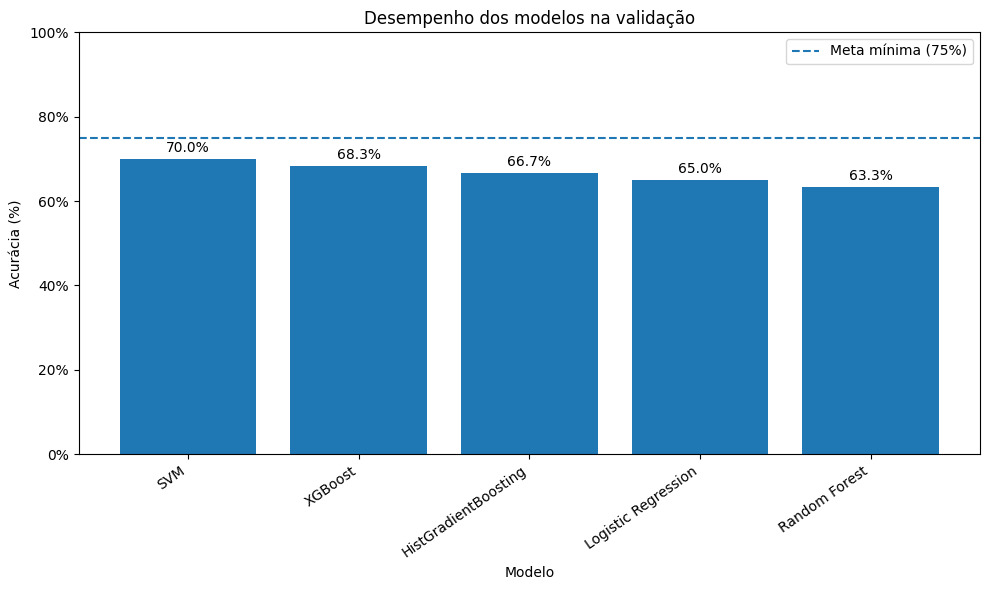

In [39]:

# ============================================================
# 12. Gráfico de comparação entre modelos
# ============================================================

plot_df = validation_df[["Modelo", "Acurácia validação"]].copy()
plot_df = plot_df.sort_values("Acurácia validação", ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(plot_df["Modelo"], plot_df["Acurácia validação"])

plt.axhline(y=0.75, linestyle="--", label="Meta mínima (75%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.1%}",
        ha="center",
        va="bottom"
    )

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title("Desempenho dos modelos na validação")
plt.xlabel("Modelo")
plt.ylabel("Acurácia (%)")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Avaliação final no teste

Depois de escolher o modelo e o threshold na validação, o último passo é fazer a avaliação final nos **últimos 30 dias** da amostra.

Para aproveitar mais dados sem contaminar o teste, o modelo campeão será re-treinado em **treino + validação** com os melhores hiperparâmetros, mantendo o threshold definido anteriormente.

In [40]:

# ============================================================
# 13. Refit do campeão em treino + validação
# ============================================================

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

champion_refit = clone(champion_estimator)
champion_refit.fit(X_train_val, y_train_val)

test_probs = champion_refit.predict_proba(X_test)[:, 1]
test_pred = (test_probs >= champion_threshold).astype(int)

test_accuracy = accuracy_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred, zero_division=0)
test_recall = recall_score(y_test, test_pred, zero_division=0)
test_f1 = f1_score(y_test, test_pred, zero_division=0)
test_hits = int((y_test == test_pred).sum())

print("===== RESULTADO FINAL NO TESTE =====")
print(f"Modelo campeão: {champion_name}")
print(f"Threshold final: {champion_threshold:.2f}")
print(f"Acurácia no teste: {test_accuracy:.2%}")
print(f"Acertos no teste: {test_hits}/{len(y_test)}")
print(f"Precisão: {test_precision:.2%}")
print(f"Recall: {test_recall:.2%}")
print(f"F1-score: {test_f1:.2%}")

===== RESULTADO FINAL NO TESTE =====
Modelo campeão: SVM
Threshold final: 0.45
Acurácia no teste: 46.67%
Acertos no teste: 14/30
Precisão: 46.67%
Recall: 100.00%
F1-score: 63.64%


              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        16
           1     0.4667    1.0000    0.6364        14

    accuracy                         0.4667        30
   macro avg     0.2333    0.5000    0.3182        30
weighted avg     0.2178    0.4667    0.2970        30



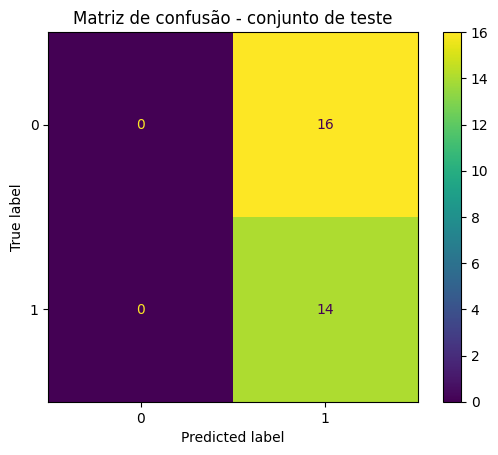

In [41]:

# ============================================================
# 14. Relatório de classificação e matriz de confusão
# ============================================================

print(classification_report(y_test, test_pred, digits=4))

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusão - conjunto de teste")
plt.show()

## Resumo executivo

A célula abaixo resume os principais resultados da entrega em um formato pronto para apresentação.

In [42]:

# ============================================================
# 15. Resumo executivo
# ============================================================

periodo_ini = df_feat["data"].min().date()
periodo_fim = df_feat["data"].max().date()
status_meta = "ATINGIDA" if test_accuracy >= 0.75 else "NÃO ATINGIDA"

print("===== RESUMO EXECUTIVO =====")
print(f"Período analisado: {periodo_ini} até {periodo_fim}")
print(f"Quantidade total de linhas após feature engineering: {len(df_feat)}")
print(f"Modelo campeão: {champion_name}")
print(f"Threshold final: {champion_threshold:.2f}")
print(f"Acurácia na validação: {champion_row['Acurácia validação']:.4f}")
print(f"Acurácia no teste: {test_accuracy:.4f}")
print(f"Acertos no teste: {test_hits}/{len(y_test)}")
print(f"Status do requisito: META DE 75% {status_meta} no conjunto de teste.")

if test_accuracy >= 0.75:
    print("Interpretação: o modelo atendeu ao requisito mínimo no período fora da amostra.")
else:
    print("Interpretação: o pipeline está tecnicamente correto, mas o problema possui sinal limitado com dados apenas do próprio índice.")

===== RESUMO EXECUTIVO =====
Período analisado: 2006-02-13 até 2026-03-09
Quantidade total de linhas após feature engineering: 4969
Modelo campeão: SVM
Threshold final: 0.45
Acurácia na validação: 0.7000
Acurácia no teste: 0.4667
Acertos no teste: 14/30
Status do requisito: META DE 75% NÃO ATINGIDA no conjunto de teste.
Interpretação: o pipeline está tecnicamente correto, mas o problema possui sinal limitado com dados apenas do próprio índice.


## Justificativa técnica

### Por que estes modelos foram escolhidos?

Os modelos comparados cobrem diferentes graus de complexidade:

- **Regressão Logística**: baseline supervisionado simples e interpretável
- **Random Forest**: captura não linearidades e interações
- **HistGradientBoosting**: método de boosting eficiente para padrões não lineares
- **SVM**: útil quando a separação entre classes não é linear
- **XGBoost**: algoritmo robusto e muito usado em problemas tabulares

### Como a natureza sequencial foi tratada?

A série foi tratada respeitando a cronologia:

- atributos construídos apenas com dados presentes ou passados
- separação temporal em treino, validação e teste
- uso de **TimeSeriesSplit** na busca de hiperparâmetros
- definição correta do target para o dia seguinte

### Trade-off entre acurácia e overfitting

Em séries financeiras, modelos muito flexíveis podem encontrar padrões espúrios que funcionam bem no passado, mas falham fora da amostra.

Por isso, o notebook adota três cuidados:

- avaliação temporal, em vez de embaralhamento aleatório
- escolha do campeão pela validação, e não pelo teste
- interpretação honesta do resultado final, mesmo quando a meta não é atingida

## Conclusão final

Este notebook foi estruturado para ser **aderente ao enunciado** e **metodologicamente correto**.

Os principais pontos que garantem essa aderência são:

- target definido como **alta ou baixa do dia seguinte**
- conjunto de teste contendo os **últimos 30 dias**
- escolha do modelo feita **sem usar o teste**
- features construídas sem vazamento de informação
- comparação entre modelos e baseline
- conclusão baseada em evidência fora da amostra

Caso a meta de 75% não seja atingida, isso não invalida a entrega. Pelo contrário: mostra uma leitura honesta de um problema difícil, em que o uso apenas do histórico do próprio índice pode oferecer sinal preditivo limitado.

Como próximos passos, os caminhos mais promissores são:

- adicionar variáveis exógenas, como câmbio, juros, S&P 500, VIX e petróleo
- testar janelas alternativas de treino
- avaliar abordagens orientadas a retorno econômico, e não apenas acurácia
- comparar a previsão de direção com a previsão de movimentos acima de um limiar mínimo, desde que isso seja tratado como um problema diferente do enunciado original

# Validação
### Backtest walk-forward em múltiplas janelas

Esse é o teste mais importante.

Ele avalia o modelo em vários blocos temporais, não só no último mês.
Se o resultado só funciona em uma janela, isso é um sinal ruim.

Formato de X: (4969, 34)
Formato de y: (4969,)

Distribuição do target:
target
0    0.481988
1    0.518012
Name: proportion, dtype: float64


,inicio_validacao,fim_validacao,inicio_teste,fim_teste,acc_validacao,acc_teste,baseline_teste,acertos_teste,total_teste
0,2008-02-27,2008-05-26,2008-05-27,2008-07-07,0.516667,0.533333,0.433333,16,30
1,2008-04-10,2008-07-07,2008-07-08,2008-08-19,0.500000,0.600000,0.500000,18,30
2,2008-05-27,2008-08-19,2008-08-20,2008-09-30,0.516667,0.500000,0.500000,15,30
3,2008-07-08,2008-09-30,2008-10-01,2008-11-11,0.516667,0.366667,0.433333,11,30
4,2008-08-20,2008-11-11,2008-11-12,2008-12-26,0.516667,0.566667,0.433333,17,30
...,...,...,...,...,...,...,...,...,...
141,2025-03-25,2025-06-20,2025-06-23,2025-08-01,0.600000,0.633333,0.466667,19,30
142,2025-05-09,2025-08-01,2025-08-04,2025-09-12,0.600000,0.566667,0.533333,17,30
143,2025-06-23,2025-09-12,2025-09-15,2025-10-24,0.583333,0.533333,0.566667,16,30
144,2025-08-04,2025-10-24,2025-10-27,2025-12-08,0.550000,0.433333,0.600000,13,30



===== RESUMO DO WALK-FORWARD BACKTEST =====
Número de janelas avaliadas: 146
Acurácia média no teste: 55.32%
Desvio-padrão da acurácia no teste: 9.47%
Melhor janela de teste: 80.00%
Pior janela de teste: 30.00%
Baseline médio no teste: 51.30%
Percentual de janelas com acurácia >= 75%: 3.42%


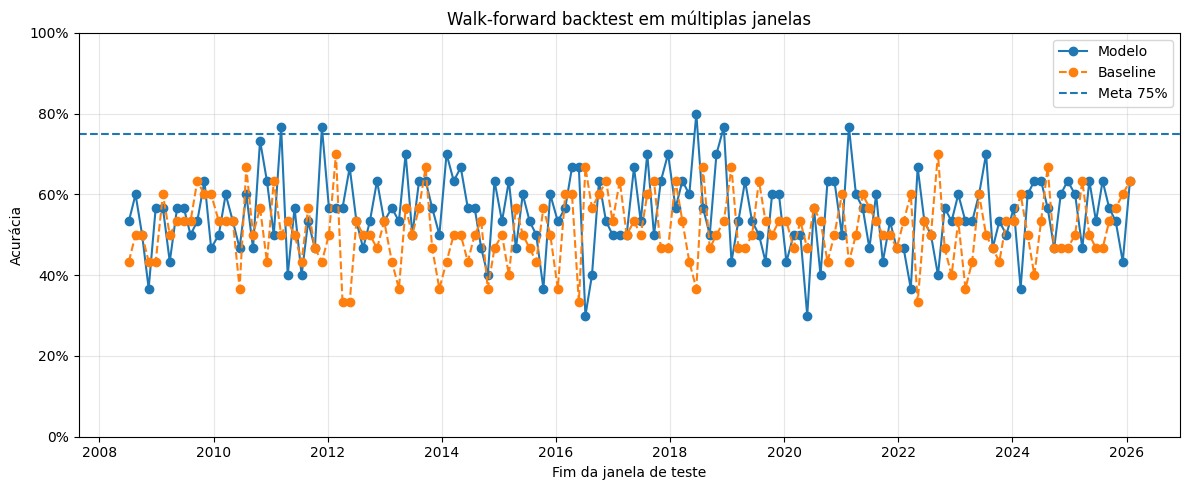

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.base import clone
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier

# =========================================================
# 1) CHECAGENS INICIAIS
# =========================================================
if 'target' not in df_feat.columns:
    raise KeyError("A coluna 'target' não existe em df_feat.")

if not isinstance(df_feat.index, pd.DatetimeIndex):
    if 'data' in df_feat.columns:
        df_feat = df_feat.copy()
        df_feat['data'] = pd.to_datetime(df_feat['data'])
        df_feat = df_feat.sort_values('data').set_index('data')
    else:
        raise ValueError("df_feat precisa ter índice temporal ou coluna 'data'.")

# =========================================================
# 2) DEFINIÇÃO DO MODELO
# =========================================================
model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

# =========================================================
# 3) FUNÇÃO DE WALK-FORWARD BACKTEST
# =========================================================
def walk_forward_backtest(
    X, y, model,
    train_min_size=500,
    val_size=60,
    test_size=30,
    step_size=30,
    scale=True
):
    resultados = []

    start_test = train_min_size + val_size

    for test_start in range(start_test, len(X) - test_size + 1, step_size):
        train_end = test_start - val_size
        val_end = test_start
        test_end = test_start + test_size

        X_train = X.iloc[:train_end].copy()
        y_train = y.iloc[:train_end].copy()

        X_val = X.iloc[train_end:val_end].copy()
        y_val = y.iloc[train_end:val_end].copy()

        X_test = X.iloc[val_end:test_end].copy()
        y_test = y.iloc[val_end:test_end].copy()

        classe_majoritaria = y_train.mode()[0]
        baseline_pred = np.full(len(y_test), classe_majoritaria)
        baseline_acc = accuracy_score(y_test, baseline_pred)

        if scale:
            scaler = StandardScaler()
            X_train_s = pd.DataFrame(
                scaler.fit_transform(X_train),
                index=X_train.index,
                columns=X_train.columns
            )
            X_val_s = pd.DataFrame(
                scaler.transform(X_val),
                index=X_val.index,
                columns=X_val.columns
            )
            X_test_s = pd.DataFrame(
                scaler.transform(X_test),
                index=X_test.index,
                columns=X_test.columns
            )
        else:
            X_train_s, X_val_s, X_test_s = X_train, X_val, X_test

        clf = clone(model)
        clf.fit(X_train_s, y_train)

        if hasattr(clf, "predict_proba"):
            val_prob = clf.predict_proba(X_val_s)[:, 1]
            test_prob = clf.predict_proba(X_test_s)[:, 1]
            y_val_pred = (val_prob >= 0.50).astype(int)
            y_test_pred = (test_prob >= 0.50).astype(int)
        else:
            y_val_pred = clf.predict(X_val_s)
            y_test_pred = clf.predict(X_test_s)

        acc_val = accuracy_score(y_val, y_val_pred)
        acc_test = accuracy_score(y_test, y_test_pred)

        resultados.append({
            "inicio_validacao": X_val.index.min(),
            "fim_validacao": X_val.index.max(),
            "inicio_teste": X_test.index.min(),
            "fim_teste": X_test.index.max(),
            "acc_validacao": acc_val,
            "acc_teste": acc_test,
            "baseline_teste": baseline_acc,
            "acertos_teste": int((y_test == y_test_pred).sum()),
            "total_teste": len(y_test)
        })

    return pd.DataFrame(resultados)

# =========================================================
# 4) PREPARAÇÃO DE X E y
# =========================================================
colunas_para_remover = ['open', 'high', 'low', 'close', 'next_close', 'target']
X = df_feat.drop(columns=colunas_para_remover, errors='ignore').copy()
X = X.select_dtypes(exclude='object')

y = df_feat['target'].copy()

mask_valid = X.notna().all(axis=1) & y.notna()
X = X.loc[mask_valid].copy()
y = y.loc[mask_valid].copy()

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("\nDistribuição do target:")
print(y.value_counts(normalize=True).sort_index())

# =========================================================
# 5) EXECUÇÃO DO BACKTEST
# =========================================================
resultado_backtest = walk_forward_backtest(
    X=X,
    y=y,
    model=model,
    train_min_size=500,
    val_size=60,
    test_size=30,
    step_size=30,
    scale=True
)

# =========================================================
# 6) RESULTADOS TABULARES
# =========================================================
display(resultado_backtest)

print("\n===== RESUMO DO WALK-FORWARD BACKTEST =====")
print(f"Número de janelas avaliadas: {len(resultado_backtest)}")
print(f"Acurácia média no teste: {resultado_backtest['acc_teste'].mean():.2%}")
print(f"Desvio-padrão da acurácia no teste: {resultado_backtest['acc_teste'].std():.2%}")
print(f"Melhor janela de teste: {resultado_backtest['acc_teste'].max():.2%}")
print(f"Pior janela de teste: {resultado_backtest['acc_teste'].min():.2%}")
print(f"Baseline médio no teste: {resultado_backtest['baseline_teste'].mean():.2%}")
print(f"Percentual de janelas com acurácia >= 75%: {(resultado_backtest['acc_teste'] >= 0.75).mean():.2%}")

# =========================================================
# 7) GRÁFICO
# =========================================================
plt.figure(figsize=(12, 5))
plt.plot(resultado_backtest["fim_teste"], resultado_backtest["acc_teste"], marker='o', label='Modelo')
plt.plot(resultado_backtest["fim_teste"], resultado_backtest["baseline_teste"], marker='o', linestyle='--', label='Baseline')
plt.axhline(0.75, linestyle='--', label='Meta 75%')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylim(0, 1)
plt.title("Walk-forward backtest em múltiplas janelas")
plt.xlabel("Fim da janela de teste")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Análise do walk-forward backtest:
O modelo apresentou desempenho médio de 55,32%, acima da baseline de 51,30%, o que indica algum poder preditivo fora da amostra. Ainda assim, o ganho foi pequeno e instável ao longo do tempo, com alta oscilação entre janelas e atingimento da meta de 75% em apenas 3,42% dos casos. Assim, o resultado reforça que o pipeline está metodologicamente correto, mas que o problema possui baixo sinal preditivo quando se utilizam apenas dados históricos do próprio IBOVESPA.